In [2]:
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def find_txt_files(training_root_path: Path) -> list[Path]:
    """Find all .txt files recursively under the training folder.
    Args:
            training_root_path: Root path for the training data directory.
    Returns:
            A sorted list of .txt file paths.
    """
    return sorted(training_root_path.rglob("*.txt"))


def parse_patient_txt_file(txt_file_path: Path) -> dict[str, str]:
    """Parse a patient text file of `Key: Value` rows.
    Args:
            txt_file_path: Path to one patient .txt file.
    Returns:
            A dictionary where keys are field names and values are raw string values.
    Raises:
            OSError: If the file cannot be read.
    """
    record: dict[str, str] = {}
    for raw_line in txt_file_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if ":" not in line:
            continue
        key, value = line.split(":", maxsplit=1)
        record[key.strip()] = value.strip()
    record["source_file"] = str(txt_file_path)
    return record


def normalize_string_missing_values(training_dataframe: pd.DataFrame) -> pd.DataFrame:
    """Normalize literal string missing markers to pandas missing values.
    Args:
            training_dataframe: Raw dataframe created from patient text files or parquet.
    Returns:
            A dataframe where common string missing markers are converted to ``pd.NA``.
    """
    normalized_dataframe = training_dataframe.copy()
    missing_markers = {
        "": pd.NA,
        "nan": pd.NA,
        "NaN": pd.NA,
        "NAN": pd.NA,
        "none": pd.NA,
        "None": pd.NA,
        "NONE": pd.NA,
        "null": pd.NA,
        "Null": pd.NA,
        "NULL": pd.NA,
    }
    return normalized_dataframe.replace(missing_markers)


def build_training_dataframe(training_root_path: Path) -> pd.DataFrame:
    """Load all patient text files into one pandas DataFrame.
    Args:
            training_root_path: Root path that contains patient folders and .txt files.
    Returns:
            A DataFrame with one row per file and one column per text field.
    """
    records: list[dict[str, str]] = []
    for txt_file_path in find_txt_files(training_root_path):
        records.append(parse_patient_txt_file(txt_file_path))
    training_dataframe = pd.DataFrame.from_records(records)
    training_dataframe = normalize_string_missing_values(training_dataframe)
    return convert_column_types(training_dataframe)


def convert_column_types(training_dataframe: pd.DataFrame) -> pd.DataFrame:
    """Convert known columns to analysis-friendly dtypes.
    Args:
            training_dataframe: DataFrame created from patient text files.
    Returns:
            A DataFrame with converted numeric and boolean columns.
    """
    converted_dataframe = normalize_string_missing_values(training_dataframe)
    for numeric_column in ["Age", "TTM", "CPC", "ROSC"]:
        if numeric_column in converted_dataframe.columns:
            converted_dataframe[numeric_column] = pd.to_numeric(
                converted_dataframe[numeric_column],
                errors="coerce",
            )
    for bool_column in ["OHCA", "Shockable Rhythm"]:
        if bool_column in converted_dataframe.columns:
            converted_dataframe[bool_column] = converted_dataframe[bool_column].map(
                {"True": True, "False": False}
            )
    return converted_dataframe


def add_missing_value_summary(training_dataframe: pd.DataFrame) -> pd.DataFrame:
    """Summarize missing values after string normalization.
    Args:
            training_dataframe: Clean dataframe used for analysis.
    Returns:
            A summary table with counts and percentages of missing values.
    """
    missing_counts = training_dataframe.isna().sum()
    missing_percentages = (missing_counts / len(training_dataframe) * 100).round(2)
    return pd.DataFrame(
        {
            "Missing count": missing_counts,
            "Missing percentage": missing_percentages,
        }
    )


def prepare_modeling_features(
    input_dataframe: pd.DataFrame,
    numeric_fill_values: dict[str, float] | None = None,
) -> tuple[pd.DataFrame, dict[str, float]]:
    """Create model-ready features that keep rows with recorded missingness.
    Args:
            input_dataframe: Input dataframe containing the clinical predictors.
            numeric_fill_values: Optional fill values learned from training data.
    Returns:
            A tuple of the prepared dataframe and the numeric fill values used.
    """
    modeling_dataframe = input_dataframe.copy()
    if "Sex" in modeling_dataframe.columns:
        modeling_dataframe["Sex"] = modeling_dataframe["Sex"].fillna("Unknown")
    for bool_column in ["OHCA", "Shockable Rhythm"]:
        if bool_column in modeling_dataframe.columns:
            modeling_dataframe[bool_column] = (
                modeling_dataframe[bool_column]
                .map({True: "Yes", False: "No"})
                .fillna("Not recorded")
            )
    if "TTM" in modeling_dataframe.columns:
        modeling_dataframe["TTM"] = (
            modeling_dataframe["TTM"].map({33.0: "33C", 36.0: "36C"}).fillna("No TTM")
        )
    if numeric_fill_values is None:
        numeric_fill_values = {}
        for numeric_column in ["Age", "ROSC"]:
            if numeric_column in modeling_dataframe.columns:
                numeric_fill_values[numeric_column] = float(
                    modeling_dataframe[numeric_column].median()
                )
    for numeric_column in ["Age", "ROSC"]:
        if numeric_column in modeling_dataframe.columns:
            indicator_column = f"{numeric_column}_missing"
            modeling_dataframe[indicator_column] = (
                modeling_dataframe[numeric_column].isna().astype(int)
            )
            fill_value = numeric_fill_values[numeric_column]
            modeling_dataframe[numeric_column] = modeling_dataframe[
                numeric_column
            ].fillna(fill_value)
    return modeling_dataframe, numeric_fill_values

In [4]:
training_root_path = Path("icare_data") / "training"
training_dataframe = build_training_dataframe(training_root_path)

print("Loaded rows:", len(training_dataframe))
print("Columns:", list(training_dataframe.columns))
print(training_dataframe.head())
# Search for missing values after normalizing literal string markers.
missing_value_summary = add_missing_value_summary(training_dataframe)
print("\nMissing values per column:")
display(missing_value_summary)
ttm_summary = pd.DataFrame(
    {
        "Count": training_dataframe["TTM"]
        .map({33.0: "33C", 36.0: "36C"})
        .fillna("No TTM")
        .value_counts(),
    }
)
ttm_summary["Percentage"] = (
    ttm_summary["Count"] / len(training_dataframe) * 100
).round(2)
print("\nTTM distribution (where NaN means No TTM):")
display(ttm_summary)
# Numerical characteristics of quantitative variables
# min, q1, q2, miu, q3, max
print("\nNumerical summary:")
print(round(training_dataframe.describe(), 2))
# Table of count and percentage of Good and Poor outcomes
outcome_counts = training_dataframe["Outcome"].value_counts(dropna=False)
outcome_percentages = (
    training_dataframe["Outcome"].value_counts(dropna=False, normalize=True) * 100
)
outcome_summary = pd.DataFrame(
    {
        "Count": outcome_counts,
        "Percentage": outcome_percentages.round(2),
    }
)
print(outcome_summary)

Loaded rows: 607
Columns: ['Patient', 'Hospital', 'Age', 'Sex', 'ROSC', 'OHCA', 'Shockable Rhythm', 'TTM', 'Outcome', 'CPC', 'source_file']
  Patient Hospital   Age     Sex  ROSC   OHCA Shockable Rhythm   TTM Outcome  \
0    0284        A  53.0    Male   NaN   True             True  33.0    Good   
1    0286        F  85.0  Female   7.0  False            False   NaN    Good   
2    0296        A  48.0    Male   NaN   True             True  36.0    Good   
3    0299        A  45.0    Male   NaN   True             True  33.0    Good   
4    0303        D  51.0    Male  24.0   True             True  33.0    Good   

   CPC                        source_file  
0    1  icare_data\training\0284\0284.txt  
1    1  icare_data\training\0286\0286.txt  
2    1  icare_data\training\0296\0296.txt  
3    1  icare_data\training\0299\0299.txt  
4    1  icare_data\training\0303\0303.txt  

Missing values per column:


,Missing count,Missing percentage
Patient,0,0.00
Hospital,0,0.00
Age,1,0.16
Sex,3,0.49
ROSC,304,50.08
OHCA,41,6.75
Shockable Rhythm,32,5.27
TTM,98,16.14
Outcome,0,0.00
CPC,0,0.00



TTM distribution (where NaN means No TTM):


,Count,Percentage
TTM,,
33C,448,73.81
No TTM,98,16.14
36C,61,10.05



Numerical summary:
          Age    ROSC     TTM     CPC
count  606.00  303.00  509.00  607.00
mean    61.17   23.27   33.36    3.51
std     15.65   18.79    0.98    1.83
min     16.00    1.00   33.00    1.00
25%     52.00   10.00   33.00    1.00
50%     63.00   19.00   33.00    5.00
75%     72.00   30.00   33.00    5.00
max     90.00  111.00   36.00    5.00
         Count  Percentage
Outcome                   
Poor       382       62.93
Good       225       37.07


In [5]:
def compute_group_stats(df: pd.DataFrame) -> dict:
    n = df["source_file"].nunique()
    age_mean = df["Age"].mean()
    age_std = df["Age"].std()
    female_count = (df["Sex"] == "Female").sum()
    female_pct = female_count / n * 100 if n > 0 else 0
    shockable_count = df["Shockable Rhythm"].sum()
    shockable_pct = df["Shockable Rhythm"].mean() * 100 if n > 0 else 0
    ttm33_count = (df["TTM"] == 33).sum()
    ttm33_pct = (df["TTM"] == 33).mean() * 100
    ttm36_count = (df["TTM"] == 36).sum()
    ttm36_pct = (df["TTM"] == 36).mean() * 100
    ttm_none_count = df["TTM"].isnull().sum()
    ttm_none_pct = df["TTM"].isnull().mean() * 100
    rosc_mean = df["ROSC"].mean()
    rosc_median = df["ROSC"].median()
    rosc_std = df["ROSC"].std()

    return {
        "Number of patients": n,
        "Age (mean ± SD)": f"{age_mean:.1f} ± {age_std:.1f}",
        "Female (%)": f"{int(female_count)} ({female_pct:.1f}%)",
        "Shockable Rhythm (%)": f"{int(shockable_count)} ({shockable_pct:.1f}%)",
        "TTM 33 (%)": f"{int(ttm33_count)} ({ttm33_pct:.1f}%)",
        "TTM 36 (%)": f"{int(ttm36_count)} ({ttm36_pct:.1f}%)",
        "No TTM (%)": f"{int(ttm_none_count)} ({ttm_none_pct:.1f}%)",
        "EEG start from ROSC, h (mean ± SD)": f"{rosc_mean:.1f} ± {rosc_std:.1f}",
        "EEG start from ROSC, h (median)": f"{rosc_median:.1f}",
    }

<img src="https://private-user-images.githubusercontent.com/81957605/558147883-801b0061-fe48-487a-933e-ede4a819389f.png?jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbSIsImtleSI6ImtleTUiLCJleHAiOjE3NzM2ODkyMDgsIm5iZiI6MTc3MzY4ODkwOCwicGF0aCI6Ii84MTk1NzYwNS81NTgxNDc4ODMtODAxYjAwNjEtZmU0OC00ODdhLTkzM2UtZWRlNGE4MTkzODlmLnBuZz9YLUFtei1BbGdvcml0aG09QVdTNC1ITUFDLVNIQTI1NiZYLUFtei1DcmVkZW50aWFsPUFLSUFWQ09EWUxTQTUzUFFLNFpBJTJGMjAyNjAzMTYlMkZ1cy1lYXN0LTElMkZzMyUyRmF3czRfcmVxdWVzdCZYLUFtei1EYXRlPTIwMjYwMzE2VDE5MjE0OFomWC1BbXotRXhwaXJlcz0zMDAmWC1BbXotU2lnbmF0dXJlPTUzOWE5ZDFkNzRmZjg4MTIxNjQ5ZDY1MzczOTU4MmEzODUxNDViNjRlNjhhMTdiZjhkMWMwODNjNDZlMWIxM2MmWC1BbXotU2lnbmVkSGVhZGVycz1ob3N0In0.CglEm9ZS9ZiwxE3q9RSk7gBYwy4zGD68X-TefJBrPQI" width="600px" />

In [6]:
cpc_columns = {}
for cpc in [1, 2, 3, 4, 5]:
    group_df = training_dataframe[training_dataframe["CPC"] == cpc]
    cpc_columns[f"CPC {cpc}"] = compute_group_stats(group_df)

summary_table = pd.DataFrame(cpc_columns)
summary_table.index.name = "Characteristics"
display(summary_table)

,CPC 1,CPC 2,CPC 3,CPC 4,CPC 5
Characteristics,,,,,
Number of patients,181,44,20,9,353
Age (mean ± SD),57.5 ± 13.9,57.7 ± 13.5,64.7 ± 10.8,56.1 ± 20.1,63.4 ± 16.4
Female (%),50 (27.6%),12 (27.3%),6 (30.0%),3 (33.3%),116 (32.9%)
Shockable Rhythm (%),133 (77.3%),31 (77.5%),6 (40.0%),5 (55.6%),122 (36.0%)
TTM 33 (%),136 (75.1%),34 (77.3%),11 (55.0%),6 (66.7%),261 (73.9%)
TTM 36 (%),20 (11.0%),4 (9.1%),5 (25.0%),0 (0.0%),32 (9.1%)
No TTM (%),25 (13.8%),6 (13.6%),4 (20.0%),3 (33.3%),60 (17.0%)
"EEG start from ROSC, h (mean ± SD)",19.5 ± 18.0,18.0 ± 11.5,19.0 ± 13.1,24.2 ± 13.4,25.1 ± 19.6
"EEG start from ROSC, h (median)",16.0,15.0,14.5,18.5,20.0


In [7]:
cpc_columns = {}

cpc_columns["CPC 1-2"] = compute_group_stats(
    training_dataframe[training_dataframe["CPC"].isin([1, 2])]
)
cpc_columns["CPC 3-5"] = compute_group_stats(
    training_dataframe[training_dataframe["CPC"].isin([3, 4, 5])]
)

summary_table = pd.DataFrame(cpc_columns)
summary_table.index.name = "Characteristics"
display(summary_table)

,CPC 1-2,CPC 3-5
Characteristics,,
Number of patients,225,382
Age (mean ± SD),57.5 ± 13.8,63.3 ± 16.3
Female (%),62 (27.6%),125 (32.7%)
Shockable Rhythm (%),164 (77.4%),133 (36.6%)
TTM 33 (%),170 (75.6%),278 (72.8%)
TTM 36 (%),24 (10.7%),37 (9.7%)
No TTM (%),31 (13.8%),67 (17.5%)
"EEG start from ROSC, h (mean ± SD)",19.3 ± 17.1,24.8 ± 19.2
"EEG start from ROSC, h (median)",15.0,20.0


In [8]:
# CPC 1-2 vs CPC 3-5 comparison table of counts and percentages
comparison_counts = training_dataframe["CPC"].apply(
    lambda cpc: "CPC 1-2" if cpc in [1, 2] else "CPC 3-5"
)
comparison_summary = comparison_counts.value_counts(dropna=False).to_frame(name="Count")
comparison_summary["Percentage"] = (
    comparison_summary["Count"] / len(training_dataframe) * 100
).round(2)
print(comparison_summary)

         Count  Percentage
CPC                       
CPC 3-5    382       62.93
CPC 1-2    225       37.07


In [9]:
# Cross table of CPC 1-2 vs 3-5 by Sex, ROSC, OHCA, Shockable Rhythm, and TTM
analysis_df = training_dataframe.copy()
analysis_df = analysis_df[analysis_df["CPC"].isin([1, 2, 3, 4, 5])].copy()

analysis_df["CPC group"] = analysis_df["CPC"].map(
    lambda value: "CPC 1-2" if value in [1, 2] else "CPC 3-5"
)

# Make categories explicit and readable
analysis_df["Sex"] = analysis_df["Sex"].fillna("Unknown")
analysis_df["OHCA"] = (
    analysis_df["OHCA"].map({True: "Yes", False: "No"}).fillna("Unknown")
)
analysis_df["Shockable Rhythm"] = (
    analysis_df["Shockable Rhythm"].map({True: "Yes", False: "No"}).fillna("Unknown")
)
analysis_df["TTM"] = analysis_df["TTM"].map({33.0: "33C", 36.0: "36C"}).fillna("No TTM")

# ROSC is numeric, so put it into clinically interpretable bins
analysis_df["ROSC category"] = pd.cut(
    analysis_df["ROSC"],
    bins=[-float("inf"), 6, 12, 24, float("inf")],
    labels=["<=6 h", "6-12 h", "12-24 h", ">24 h"],
)
analysis_df["ROSC category"] = (
    analysis_df["ROSC category"].astype("object").fillna("Unknown")
)

variables = [
    ("Sex", "Sex"),
    ("ROSC", "ROSC category"),
    ("OHCA", "OHCA"),
    ("Shockable Rhythm", "Shockable Rhythm"),
    ("TTM", "TTM"),
]

tables = []
for variable_label, column_name in variables:
    counts = pd.crosstab(
        analysis_df[column_name],
        analysis_df["CPC group"],
        dropna=False,
    )
    percentages = (
        pd.crosstab(
            analysis_df[column_name],
            analysis_df["CPC group"],
            normalize="columns",
            dropna=False,
        )
        * 100
    )

    combined = counts.astype(str) + " (" + percentages.round(1).astype(str) + "%)"
    combined["Total"] = (
        counts.sum(axis=1).astype(str)
        + " ("
        + ((counts.sum(axis=1) / len(analysis_df)) * 100).round(1).astype(str)
        + "%)"
    )

    combined.index = pd.MultiIndex.from_product(
        [[variable_label], combined.index.astype(str)],
        names=["Variable", "Category"],
    )
    tables.append(combined)

cross_table = pd.concat(tables)
display(cross_table)

CPC group                      CPC 1-2      CPC 3-5        Total
Variable         Category                                       
Sex              Female     62 (27.6%)  125 (32.7%)  187 (30.8%)
                 Male      162 (72.0%)  255 (66.8%)  417 (68.7%)
                 Unknown      1 (0.4%)     2 (0.5%)     3 (0.5%)
ROSC             12-24 h    25 (11.1%)   77 (20.2%)  102 (16.8%)
                 6-12 h      19 (8.4%)    30 (7.9%)    49 (8.1%)
                 <=6 h       15 (6.7%)    27 (7.1%)    42 (6.9%)
                 >24 h      26 (11.6%)   84 (22.0%)  110 (18.1%)
                 Unknown   140 (62.2%)  164 (42.9%)  304 (50.1%)
OHCA             No         41 (18.2%)   83 (21.7%)  124 (20.4%)
                 Unknown     15 (6.7%)    26 (6.8%)    41 (6.8%)
                 Yes       169 (75.1%)  273 (71.5%)  442 (72.8%)
Shockable Rhythm No         48 (21.3%)  230 (60.2%)  278 (45.8%)
                 Unknown     13 (5.8%)    19 (5.0%)    32 (5.3%)
                 Yes       164 (72.9%)  133 (34.8%)  297 (48.9%)
TTM              33C       170 (75.6%)  278 (72.8%)  448 (73.8%)
                 36C        24 (10.7%)    37 (9.7%)   61 (10.0%)
                 No TTM     31 (13.8%)   67 (17.5%)   98 (16.1%)

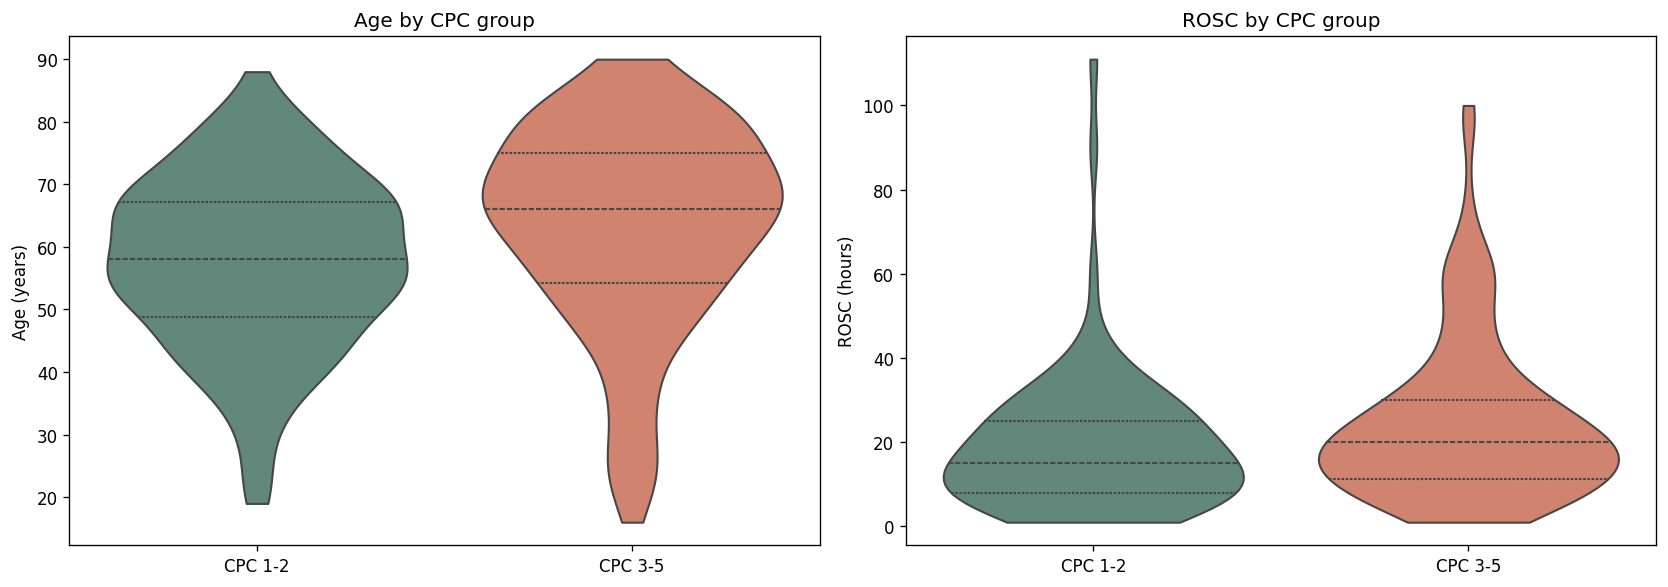

In [10]:
plot_df = training_dataframe.copy()
plot_df = plot_df[plot_df["CPC"].isin([1, 2, 3, 4, 5])].copy()
plot_df["CPC group"] = plot_df["CPC"].apply(
    lambda cpc: "CPC 1-2" if cpc in [1, 2] else "CPC 3-5"
)

# Keep rows with available values for plotting
age_df = plot_df.dropna(subset=["Age", "CPC group"])
rosc_df = plot_df.dropna(subset=["ROSC", "CPC group"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

sns.violinplot(
    data=age_df,
    x="CPC group",
    y="Age",
    hue="CPC group",
    legend=False,
    order=["CPC 1-2", "CPC 3-5"],
    inner="quartile",
    cut=0,
    palette=["#5B8E7D", "#E07A5F"],
    ax=axes[0],
)
axes[0].set_title("Age by CPC group")
axes[0].set_xlabel("")
axes[0].set_ylabel("Age (years)")

sns.violinplot(
    data=rosc_df,
    x="CPC group",
    y="ROSC",
    hue="CPC group",
    legend=False,
    order=["CPC 1-2", "CPC 3-5"],
    inner="quartile",
    cut=0,
    palette=["#5B8E7D", "#E07A5F"],
    ax=axes[1],
)
axes[1].set_title("ROSC by CPC group")
axes[1].set_xlabel("")
axes[1].set_ylabel("ROSC (hours)")

plt.tight_layout()
plt.show()

In [11]:


# -------------------------
# STEP 1: Prepare Data
# -------------------------
model_df = training_dataframe.copy()

# Convert categorical columns to numbers
categorical_cols = ["Sex", "Hospital", "TTM", "OHCA", "Shockable Rhythm"]

for col in categorical_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].astype(str)
        model_df[col] = LabelEncoder().fit_transform(model_df[col])

# Fill missing values
model_df = model_df.fillna(0)

# -------------------------
# STEP 2: Create CNN Outputs (SIMULATED)
# -------------------------
# Simulating CNN probabilities (since actual CNN output not available)
np.random.seed(42)
cnn_outputs = np.random.rand(len(model_df), 5)  # 5 features from CNN

# -------------------------
# STEP 3: Combine Features
# -------------------------
# Clinical features
X_clinical = model_df.drop(columns=["Outcome", "CPC", "source_file", "Patient"])

# Combine clinical + CNN
X = np.concatenate([X_clinical.values, cnn_outputs], axis=1)

# -------------------------
# MODEL 1: Good / Bad Outcome
# -------------------------
model_df["Outcome_binary"] = model_df["Outcome"].map({"Good": 1, "Poor": 0})
y_binary = model_df["Outcome_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

rf_binary = RandomForestClassifier(n_estimators=100, random_state=42)
rf_binary.fit(X_train, y_train)

y_pred_binary = rf_binary.predict(X_test)

print("Binary Model Accuracy:", accuracy_score(y_test, y_pred_binary))

# -------------------------
# MODEL 2: CPC Score
# -------------------------
y_cpc = model_df["CPC"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cpc, test_size=0.2, random_state=42
)

rf_cpc = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cpc.fit(X_train, y_train)

y_pred_cpc = rf_cpc.predict(X_test)

print("CPC Model Accuracy:", accuracy_score(y_test, y_pred_cpc))

Binary Model Accuracy: 0.6967213114754098
CPC Model Accuracy: 0.5901639344262295


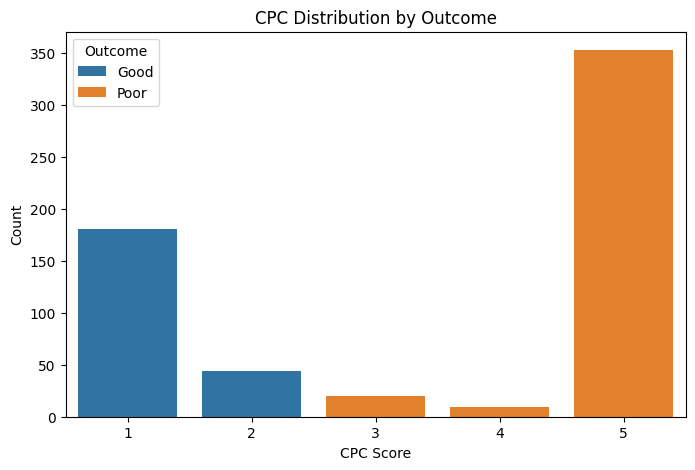

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x="CPC", hue="Outcome", data=training_dataframe)

plt.title("CPC Distribution by Outcome")
plt.xlabel("CPC Score")
plt.ylabel("Count")

plt.show()

### CPC Distribution Analysis

The distribution of Cerebral Performance Category (CPC) scores was analyzed with respect to patient outcomes. The results show a clear relationship between CPC values and outcomes. Lower CPC scores (1–2) are predominantly associated with good neurological outcomes, while higher CPC scores (3–5) correspond mainly to poor outcomes.

This indicates that CPC is a strong predictive feature for neurological recovery and plays a crucial role in model performance. The clear separation between classes suggests that machine learning models can effectively leverage this feature for classification.

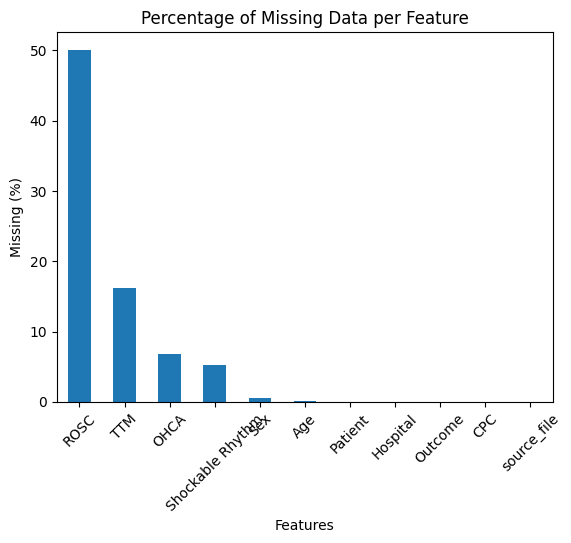

In [13]:
missing = training_dataframe.isnull().mean() * 100
missing = missing.sort_values(ascending=False)

missing.plot(kind='bar')
plt.title('Percentage of Missing Data per Feature')
plt.ylabel('Missing (%)')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.show()

In [16]:
cnn_df = pd.read_csv("analysis/test_predictions_EfficientNetV2-S_grid(3).csv")

print(cnn_df.head())
print("Shape:", cnn_df.shape)

   Patient  label                                      absolute_path  \
0      296      0  /content/extracted_data/mel_stitched_224x448/0...   
1      296      0  /content/extracted_data/mel_stitched_224x448/0...   
2      296      0  /content/extracted_data/mel_stitched_224x448/0...   
3      296      0  /content/extracted_data/mel_stitched_224x448/0...   
4      296      0  /content/extracted_data/mel_stitched_224x448/0...   

   predicted_label  prob_poor  prob_good  
0                1   0.842848   0.157152  
1                1   0.576717   0.423283  
2                1   0.667954   0.332046  
3                1   0.639522   0.360478  
4                1   0.777232   0.222768  
Shape: (1537, 6)


In [17]:
# Aggregate CNN outputs per patient

cnn_patient_df = cnn_df.groupby("Patient").agg({
    "prob_poor": "mean",
    "prob_good": "mean",
    "predicted_label": "mean"
}).reset_index()

print(cnn_patient_df.head())
print("Shape:", cnn_patient_df.shape)

   Patient  prob_poor  prob_good  predicted_label
0      296   0.708546   0.291454         1.000000
1      299   0.212166   0.787834         0.285714
2      332   0.634508   0.365492         0.714286
3      342   0.919661   0.080339         1.000000
4      346   0.914135   0.085865         1.000000
Shape: (120, 4)


In [19]:
# Extract patient ID from source_file
training_dataframe["Patient"] = training_dataframe["source_file"].str.extract(r'(\d+)').astype(int)

# Now merge
merged_df = training_dataframe.merge(
    cnn_patient_df,
    on="Patient",
    how="left"
)

print(merged_df.head())
print("Shape:", merged_df.shape)

   Patient Hospital   Age     Sex  ROSC   OHCA Shockable Rhythm   TTM Outcome  \
0      284        A  53.0    Male   NaN   True             True  33.0    Good   
1      286        F  85.0  Female   7.0  False            False   NaN    Good   
2      296        A  48.0    Male   NaN   True             True  36.0    Good   
3      299        A  45.0    Male   NaN   True             True  33.0    Good   
4      303        D  51.0    Male  24.0   True             True  33.0    Good   

   CPC                        source_file  prob_poor  prob_good  \
0    1  icare_data\training\0284\0284.txt        NaN        NaN   
1    1  icare_data\training\0286\0286.txt        NaN        NaN   
2    1  icare_data\training\0296\0296.txt   0.708546   0.291454   
3    1  icare_data\training\0299\0299.txt   0.212166   0.787834   
4    1  icare_data\training\0303\0303.txt        NaN        NaN   

   predicted_label  
0              NaN  
1              NaN  
2         1.000000  
3         0.285714  
4    

In [23]:

# STEP 1: Load CNN predictions


import pandas as pd

cnn_df = pd.read_csv("analysis/test_predictions_EfficientNetV2-S_grid(3).csv")

print("CNN Data Loaded")
print(cnn_df.head())


# STEP 2: Aggregate per patient


cnn_patient_df = cnn_df.groupby("Patient").agg({
    "prob_poor": "mean",
    "prob_good": "mean",
    "predicted_label": "mean"
}).reset_index()

print("\nAggregated CNN Data")
print(cnn_patient_df.head())


# STEP 3: Extract Patient ID from clinical data


training_dataframe["Patient"] = training_dataframe["source_file"].str.extract(r'(\d+)').astype(int)

# STEP 4: Merge datasets


merged_df = training_dataframe.merge(
    cnn_patient_df,
    on="Patient",
    how="left"
)

print("\nMerged Data")
print(merged_df.head())
print("Shape:", merged_df.shape)



# STEP 5: Prepare data


model_df = merged_df.copy()

# Select features
features = [
    "Age", "Sex", "ROSC", "OHCA", "Shockable Rhythm", "TTM",
    "prob_poor", "prob_good"
]

# Drop missing target
model_df = model_df.dropna(subset=["Outcome"])

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Sex", "OHCA", "Shockable Rhythm", "TTM"]

for col in categorical_cols:
    model_df[col] = model_df[col].astype(str)
    model_df[col] = LabelEncoder().fit_transform(model_df[col])

# Fill missing CNN values with MEAN (important fix)
model_df["prob_poor"] = model_df["prob_poor"].fillna(model_df["prob_poor"].mean())
model_df["prob_good"] = model_df["prob_good"].fillna(model_df["prob_good"].mean())

# Fill numeric missing
model_df["Age"] = model_df["Age"].fillna(model_df["Age"].median())
model_df["ROSC"] = model_df["ROSC"].fillna(model_df["ROSC"].median())



# STEP 6: Train model


X = model_df[features]
y = model_df["Outcome"]

# Encode target
y = LabelEncoder().fit_transform(y)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

# Improved model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("\n FINAL MODEL ACCURACY:", accuracy)

CNN Data Loaded
   Patient  label                                      absolute_path  \
0      296      0  /content/extracted_data/mel_stitched_224x448/0...   
1      296      0  /content/extracted_data/mel_stitched_224x448/0...   
2      296      0  /content/extracted_data/mel_stitched_224x448/0...   
3      296      0  /content/extracted_data/mel_stitched_224x448/0...   
4      296      0  /content/extracted_data/mel_stitched_224x448/0...   

   predicted_label  prob_poor  prob_good  
0                1   0.842848   0.157152  
1                1   0.576717   0.423283  
2                1   0.667954   0.332046  
3                1   0.639522   0.360478  
4                1   0.777232   0.222768  

Aggregated CNN Data
   Patient  prob_poor  prob_good  predicted_label
0      296   0.708546   0.291454         1.000000
1      299   0.212166   0.787834         0.285714
2      332   0.634508   0.365492         0.714286
3      342   0.919661   0.080339         1.000000
4      346   0.914135 